In [1]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd
from utils import simulate_bagging_and_variance, save_results_png, save_result_csv
import pandas as pd
import os

In [2]:
####### Simulation parameters  #####################
n = 500
n_sim = 1_000
B = 10_000
args = {"max_leaf_nodes": 5}
seed = 42

####### sim description ############################
text = "ohne independency correction \nmit emp std für Konfidenzintervall\nohne weighted Bootstrap"
folder_name = "figure2_wager"

# folder for figures and text
def make_folder(folder_name,text,n):
    folder_name2 = folder_name + "_nx" + str(n)
    if not os.path.exists("./figures/" + folder_name2):
        os.makedirs("./figures/" + folder_name2)
    with open("./figures/" + folder_name2 + "/readme.txt", "w") as f:
        f.write(text)
        
make_folder(folder_name,text,n)

Simulations: 100%|██████████| 1000/1000 [42:15<00:00,  2.54s/simulation]


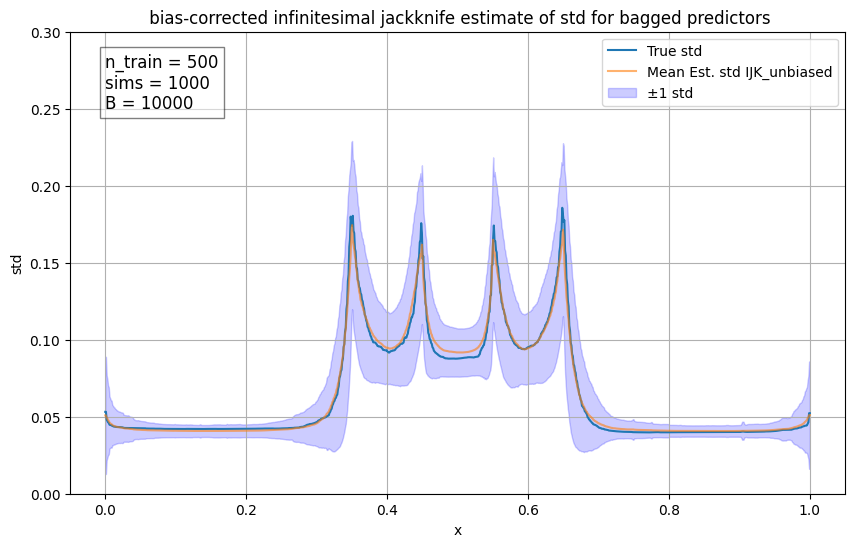

In [3]:
# data for simulations
x_fix = np.linspace(0, 1, n)
new_data = np.linspace(0, 1, 2 * n)

# run simulations
with ProcessPoolExecutor() as executor:
    
    bagged_preds = np.zeros((n_sim, new_data.shape[0]))
    biased_var_estimates = np.zeros((n_sim, new_data.shape[0]))
    bias_corrections = np.zeros((n_sim, new_data.shape[0]))
    
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
            x1=x_fix,
            B=B,
            new_data=new_data,
            simulation_index=i,
            seed=seed,
            dt_args=args,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds[i, :] = bagged_prediction
        biased_var_estimates[i, :] = biased_var_estimate
        bias_corrections[i, :] = bias_correction

# save results
save_result_csv(
    seed=seed,
    B=B,
    args=args,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    new_data=new_data,
    folder_name=folder_name + f"_nx{n}",
)

save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    folder_name=folder_name + f"_nx{n}",
    n_data_points=n,
    B=B,
    seed=seed,
    dt_args=args,
)